# Entrenamiento Binario de Columna Thoracolumbar - Colab

Version para Google Colab del notebook oficial de etapa 1.

Objetivo:
1. entrenar un modelo binario para localizar la columna
2. guardar el mejor checkpoint binario
3. guardar el split oficial train/val/test

Este notebook asume que la carpeta completa del proyecto esta en Google Drive.

## 0. Preparacion de Colab

Ajusta `PROJECT_ROOT` a la carpeta del proyecto dentro de tu Google Drive.

In [1]:
import os
from pathlib import Path

#try:
    #from google.colab import drive  # type: ignore
    #drive.mount('/content/drive')
#except Exception as exc:
    #print('No se detecto entorno Colab o Drive ya estaba montado:', exc)

PROJECT_ROOT = Path('./Scoliosis_Dataset')
if not PROJECT_ROOT.exists():
    raise FileNotFoundError(
        f'No existe PROJECT_ROOT={PROJECT_ROOT}. Ajusta esta ruta a tu carpeta real en Google Drive.'
    )

os.chdir(PROJECT_ROOT)
print('Working directory:', Path.cwd())

Working directory: /Users/camilo/Documents/WorkSpace/IA-MASTER/ProyectoGrado2/Scoliosis_Dataset


## 1. Librerias y configuracion

In [2]:
from __future__ import annotations

import json
import math
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import GroupShuffleSplit

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

CWD = Path.cwd()

ROOT_CANDIDATES = [
    CWD,
    CWD / "Scoliosis_Dataset",
    CWD / "IA-MASTER/ProyectoGrado2/Scoliosis_Dataset",
    CWD.parent / "Scoliosis_Dataset",
]

REQUIRED_FILES = [
    "indice_dataset.csv",
    "diccionario_etiquetas_T1_T12_L1_L5.json",
    "reporte_por_mascara_version_final.csv",
    "resumen_version_final_T1_T12_L1_L5.csv",
]


def is_valid_root(path: Path) -> bool:
    return path.exists() and all((path / name).exists() for name in REQUIRED_FILES)


ROOT = next((p for p in ROOT_CANDIDATES if is_valid_root(p)), None)

assert ROOT is not None, (
    "No se pudo localizar la carpeta Scoliosis_Dataset con los archivos esperados. "
    f"Directorio actual: {CWD}"
)

ROOT = ROOT.resolve()
print("CWD:", CWD)
print("ROOT:", ROOT)

LOCAL_CACHE_DIR = Path("/tmp/data_radiografias_colab_cache")
LOCAL_CACHE_DIR.mkdir(parents=True, exist_ok=True)

ANALYSIS_DIR = ROOT / "analysis_outputs"
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

INDEX_PATH = ROOT / "indice_dataset.csv"
MANIFEST_PATH = ROOT / "analysis_outputs" / "training_manifest_thoracolumbar.csv"
OUTPUT_DIR = ROOT / "analysis_outputs" / "training_runs_binary_thoracolumbar"
MODEL_DIR = ROOT / "models"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

if not INDEX_PATH.exists():
    raise FileNotFoundError(f"No existe {INDEX_PATH}")
if not MANIFEST_PATH.exists():
    raise FileNotFoundError(
        f"No existe {MANIFEST_PATH}. Primero corre el notebook de analisis en Colab."
    )

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

PIN_MEMORY = False

IMG_SIZE = (512, 256)
BATCH_SIZE = 4
NUM_WORKERS = 0
LR = 8e-4
WEIGHT_DECAY = 1e-4
EPOCHS = 24
PATIENCE_EARLY_STOP = 6
TEST_RATIO = 0.20
VAL_RATIO_WITHIN_DEV = 0.20
BINARY_THRESHOLD = 0.50
THRESHOLD_CANDIDATES = [0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65]
TRAIN_HFLIP_PROB = 0.50
TRAIN_BRIGHTNESS_JITTER = 0.10
TRAIN_CONTRAST_JITTER = 0.10
GRAD_CLIP_NORM = 1.0

index_df_raw = pd.read_csv(INDEX_PATH)
manifest_df = pd.read_csv(MANIFEST_PATH)

index_col_map = {
    "grupo": "split",
    "imagen": "image",
    "id_paciente": "patient_id",
    "ruta_radiografia": "radiograph_path",
    "ruta_mascara_binaria": "label_binary_path",
}
index_df = index_df_raw.rename(columns=index_col_map).copy()

join_cols = ["split", "image", "patient_id", "radiograph_path"]
dataset_subset = index_df[join_cols + ["label_binary_path"]].copy()
train_table = manifest_df.merge(dataset_subset, on=join_cols, how="left")
train_table["radiograph_path_abs"] = train_table["radiograph_path"].apply(lambda rel: str((ROOT / rel).resolve()))
train_table["binary_mask_path_abs"] = train_table["label_binary_path"].apply(lambda rel: str((ROOT / rel).resolve()))

for col in ["usable_for_binary_spine", "needs_annotation_review"]:
    if col in train_table.columns:
        train_table[col] = train_table[col].map(
            lambda x: x if isinstance(x, bool) else str(x).strip().lower() == "true"
        )

binary_df = train_table.loc[train_table["usable_for_binary_spine"]].copy()
print("ROOT:", ROOT)
print("DEVICE:", DEVICE)
print("Total muestras:", len(train_table))
print("Muestras para binario:", len(binary_df))
display(binary_df.head())


CWD: /Users/camilo/Documents/WorkSpace/IA-MASTER/ProyectoGrado2/Scoliosis_Dataset
ROOT: /Users/camilo/Documents/WorkSpace/IA-MASTER/ProyectoGrado2/Scoliosis_Dataset
ROOT: /Users/camilo/Documents/WorkSpace/IA-MASTER/ProyectoGrado2/Scoliosis_Dataset
DEVICE: mps
Total muestras: 250
Muestras para binario: 250


,split,image,patient_id,radiograph_path,mask_path,num_visible_target_vertebrae,first_visible_target,last_visible_target,visible_target_span_signature,present_target_vertebrae,...,present_L4,present_L5,all_core_labels_present,usable_for_binary_spine,usable_for_thoracolumbar_core,usable_for_thoracolumbar_partial,needs_annotation_review,usable_for_cobb_regression,label_binary_path,binary_mask_path_abs
0,Normal,N_1.jpg,1,Normal/N_1.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_1.png,17,T1,L5,T1-L5,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",...,1,1,True,True,True,True,False,False,LabelBinaryJPG/Label_N_1.jpg,/Users/camilo/Documents/WorkSpace/IA-MASTER/Pr...
1,Normal,N_2.jpg,2,Normal/N_2.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_2.png,17,T1,L5,T1-L5,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",...,1,1,True,True,True,True,False,False,LabelBinaryJPG/Label_N_2.jpg,/Users/camilo/Documents/WorkSpace/IA-MASTER/Pr...
2,Normal,N_3.jpg,3,Normal/N_3.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_3.png,17,T1,L5,T1-L5,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",...,1,1,True,True,True,True,False,False,LabelBinaryJPG/Label_N_3.jpg,/Users/camilo/Documents/WorkSpace/IA-MASTER/Pr...
3,Normal,N_4.jpg,4,Normal/N_4.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_4.png,17,T1,L5,T1-L5,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",...,1,1,True,True,True,True,False,False,LabelBinaryJPG/Label_N_4.jpg,/Users/camilo/Documents/WorkSpace/IA-MASTER/Pr...
4,Normal,N_5.jpg,5,Normal/N_5.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_5.png,17,T1,L5,T1-L5,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",...,1,1,True,True,True,True,False,False,LabelBinaryJPG/Label_N_5.jpg,/Users/camilo/Documents/WorkSpace/IA-MASTER/Pr...


## 2. Split train / val / test

In [3]:
def make_group_train_val_test_split(
    df_in: pd.DataFrame,
    test_ratio: float = 0.20,
    val_ratio_within_dev: float = 0.20,
    seed: int = 42,
) -> pd.DataFrame:
    work = df_in.reset_index(drop=True).copy()
    holdout_splitter = GroupShuffleSplit(n_splits=1, test_size=test_ratio, random_state=seed)
    dev_idx, test_idx = next(holdout_splitter.split(work, groups=work['group_id_for_split']))
    dev_df = work.iloc[dev_idx].copy()
    test_df = work.iloc[test_idx].copy()

    val_splitter = GroupShuffleSplit(n_splits=1, test_size=val_ratio_within_dev, random_state=seed)
    train_idx, val_idx = next(val_splitter.split(dev_df, groups=dev_df['group_id_for_split']))
    train_df = dev_df.iloc[train_idx].copy()
    val_df = dev_df.iloc[val_idx].copy()

    train_df['partition'] = 'train'
    val_df['partition'] = 'val'
    test_df['partition'] = 'test'
    return pd.concat([train_df, val_df, test_df], ignore_index=True)


binary_splits_df = make_group_train_val_test_split(binary_df, test_ratio=TEST_RATIO, val_ratio_within_dev=VAL_RATIO_WITHIN_DEV, seed=SEED)

split_path = OUTPUT_DIR / 'binary_spine_split_train_val_test.csv'
group_map_path = OUTPUT_DIR / 'binary_spine_group_partition_map.csv'
binary_splits_df.to_csv(split_path, index=False)
(
    binary_splits_df[['group_id_for_split', 'partition']]
    .drop_duplicates()
    .sort_values(['partition', 'group_id_for_split'])
    .to_csv(group_map_path, index=False)
)

display(binary_splits_df.groupby(['partition', 'split']).size().rename('images').reset_index())
display(binary_splits_df.groupby('partition')['group_id_for_split'].nunique().rename('groups').reset_index())

,partition,split,images
0,test,Normal,18
1,test,Scoliosis,32
2,train,Normal,47
3,train,Scoliosis,113
4,val,Normal,6
5,val,Scoliosis,34


,partition,groups
0,test,50
1,train,160
2,val,40


## 3. Dataset, arquitectura y metricas

In [4]:
def resolve_dataset_path(path_value: str | Path) -> Path:
    raw = Path(str(path_value))

    candidates = []

    if raw.is_absolute():
        candidates.append(raw)
    else:
        candidates.append(raw)

        base_candidates = []
        if "ROOT" in globals():
            base_candidates.append(Path(ROOT))
        base_candidates.append(Path.cwd())
        base_candidates.extend(Path.cwd().parents)

        for base in base_candidates:
            candidates.append(base / raw)

        parts = raw.parts
        if "Scoliosis_Dataset" in parts:
            idx = parts.index("Scoliosis_Dataset")
            trimmed = Path(*parts[idx + 1 :])
            if str(trimmed) not in {"", "."}:
                if "ROOT" in globals():
                    candidates.append(Path(ROOT) / trimmed)
                candidates.append(Path.cwd() / trimmed)

    seen = set()
    unique_candidates = []
    for candidate in candidates:
        key = str(candidate)
        if key not in seen:
            seen.add(key)
            unique_candidates.append(candidate)

    for candidate in unique_candidates:
        if candidate.exists():
            return candidate.resolve()

    return unique_candidates[-1].resolve()


def read_gray(path: str) -> np.ndarray:
    return np.array(Image.open(path).convert("L"))


def resize_image(arr: np.ndarray, size: tuple[int, int]) -> np.ndarray:
    return np.array(
        Image.fromarray(arr).resize((size[1], size[0]), resample=Image.BILINEAR)
    )


def resize_mask(arr: np.ndarray, size: tuple[int, int]) -> np.ndarray:
    return np.array(
        Image.fromarray(arr.astype(np.uint8)).resize(
            (size[1], size[0]),
            resample=Image.NEAREST,
        )
    )


def build_binary_mask(path: str, size: tuple[int, int] | None = None) -> np.ndarray:
    mask = read_gray(path)
    mask = (mask >= 127).astype(np.uint8)
    if size is not None:
        mask = resize_mask(mask, size)
    return mask


def apply_intensity_jitter(image_2d: np.ndarray, brightness: float = 0.10, contrast: float = 0.10) -> np.ndarray:
    gain = 1.0 + np.random.uniform(-contrast, contrast)
    bias = np.random.uniform(-brightness, brightness)
    out = image_2d * gain + bias
    return np.clip(out, 0.0, 1.0)


class BinarySpineDataset(Dataset):
    def __init__(
        self,
        table: pd.DataFrame,
        image_size: tuple[int, int],
        apply_hflip: bool = False,
        apply_intensity_aug: bool = False,
    ):
        work = table.reset_index(drop=True).copy()
        work["radiograph_path_abs"] = work["radiograph_path_abs"].apply(
            lambda p: str(resolve_dataset_path(p))
        )
        work["binary_mask_path_abs"] = work["binary_mask_path_abs"].apply(
            lambda p: str(resolve_dataset_path(p))
        )
        work["image_exists"] = work["radiograph_path_abs"].apply(lambda p: Path(p).exists())
        work["mask_exists"] = work["binary_mask_path_abs"].apply(lambda p: Path(p).exists())

        missing = work.loc[~(work["image_exists"] & work["mask_exists"])].copy()
        if not missing.empty:
            print(f"BinarySpineDataset: excluyendo {len(missing)} muestras con archivos faltantes")

        self.table = work.loc[
            work["image_exists"] & work["mask_exists"]
        ].reset_index(drop=True).copy()
        self.image_size = image_size
        self.apply_hflip = apply_hflip
        self.apply_intensity_aug = apply_intensity_aug

    def __len__(self) -> int:
        return len(self.table)

    def __getitem__(self, idx: int) -> dict:
        row = self.table.iloc[idx]
        image_path = Path(row["radiograph_path_abs"])
        mask_path = Path(row["binary_mask_path_abs"])

        image_raw = read_gray(str(image_path))
        image_resized = resize_image(image_raw, self.image_size).astype(np.float32) / 255.0
        mask = build_binary_mask(str(mask_path), size=self.image_size).astype(np.float32)

        if self.apply_hflip and np.random.rand() < TRAIN_HFLIP_PROB:
            image_resized = np.ascontiguousarray(np.fliplr(image_resized))
            mask = np.ascontiguousarray(np.fliplr(mask))

        if self.apply_intensity_aug:
            image_resized = apply_intensity_jitter(
                image_resized,
                brightness=TRAIN_BRIGHTNESS_JITTER,
                contrast=TRAIN_CONTRAST_JITTER,
            )

        image_resized = np.expand_dims(image_resized, axis=0)
        mask = np.expand_dims(mask, axis=0)

        return {
            "image": torch.tensor(image_resized, dtype=torch.float32),
            "mask": torch.tensor(mask, dtype=torch.float32),
            "sample_id": row["unique_sample_id"],
        }


class DoubleConv(nn.Module):
    def __init__(self, c_in: int, c_out: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(c_in, c_out, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(c_out),
            nn.ReLU(inplace=True),
            nn.Conv2d(c_out, c_out, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(c_out),
            nn.ReLU(inplace=True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class UNetSmall(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, base: int = 32):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.e1 = DoubleConv(in_channels, base)
        self.e2 = DoubleConv(base, base * 2)
        self.e3 = DoubleConv(base * 2, base * 4)
        self.e4 = DoubleConv(base * 4, base * 8)
        self.b = DoubleConv(base * 8, base * 16)
        self.u4 = nn.ConvTranspose2d(base * 16, base * 8, kernel_size=2, stride=2)
        self.d4 = DoubleConv(base * 16, base * 8)
        self.u3 = nn.ConvTranspose2d(base * 8, base * 4, kernel_size=2, stride=2)
        self.d3 = DoubleConv(base * 8, base * 4)
        self.u2 = nn.ConvTranspose2d(base * 4, base * 2, kernel_size=2, stride=2)
        self.d2 = DoubleConv(base * 4, base * 2)
        self.u1 = nn.ConvTranspose2d(base * 2, base, kernel_size=2, stride=2)
        self.d1 = DoubleConv(base * 2, base)
        self.head = nn.Conv2d(base, out_channels, kernel_size=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        e1 = self.e1(x)
        e2 = self.e2(self.pool(e1))
        e3 = self.e3(self.pool(e2))
        e4 = self.e4(self.pool(e3))
        b = self.b(self.pool(e4))
        d4 = self.d4(torch.cat([self.u4(b), e4], dim=1))
        d3 = self.d3(torch.cat([self.u3(d4), e3], dim=1))
        d2 = self.d2(torch.cat([self.u2(d3), e2], dim=1))
        d1 = self.d1(torch.cat([self.u1(d2), e1], dim=1))
        return self.head(d1)


def dice_loss_binary(logits: torch.Tensor, targets: torch.Tensor, eps: float = 1e-6) -> torch.Tensor:
    probs = torch.sigmoid(logits)
    intersection = (probs * targets).sum(dim=(1, 2, 3))
    denominator = probs.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))
    dice = (2.0 * intersection + eps) / (denominator + eps)
    return 1.0 - dice.mean()


def evaluate_binary(
    model: nn.Module,
    loader: DataLoader,
    bce_loss: nn.Module,
    threshold: float = 0.50,
) -> dict[str, float]:
    model.eval()
    total_loss = 0.0
    total_batches = 0
    intersection = 0.0
    pred_area = 0.0
    target_area = 0.0
    correct = 0.0
    total_pixels = 0.0

    with torch.no_grad():
        for batch in loader:
            images = batch["image"].to(DEVICE)
            targets = batch["mask"].to(DEVICE)
            logits = model(images)
            loss = bce_loss(logits, targets) + dice_loss_binary(logits, targets)
            total_loss += float(loss.item())
            total_batches += 1
            preds = (torch.sigmoid(logits) >= threshold).float()
            intersection += float((preds * targets).sum().item())
            pred_area += float(preds.sum().item())
            target_area += float(targets.sum().item())
            correct += float((preds == targets).sum().item())
            total_pixels += float(targets.numel())

    union = pred_area + target_area - intersection
    return {
        "loss": total_loss / max(total_batches, 1),
        "dice": (2.0 * intersection + 1e-6) / (pred_area + target_area + 1e-6),
        "iou": (intersection + 1e-6) / (union + 1e-6),
        "pixel_accuracy": (correct + 1e-6) / (total_pixels + 1e-6),
        "threshold": float(threshold),
    }


def estimate_binary_pos_weight(table: pd.DataFrame) -> float:
    pos_pixels = 0.0
    neg_pixels = 0.0
    for _, row in table.reset_index(drop=True).iterrows():
        mask = build_binary_mask(str(resolve_dataset_path(row["binary_mask_path_abs"])), size=IMG_SIZE)
        pos = float(mask.sum())
        total = float(mask.size)
        pos_pixels += pos
        neg_pixels += total - pos
    if pos_pixels <= 0:
        return 1.0
    return float(np.clip(neg_pixels / pos_pixels, 1.0, 12.0))


def sweep_binary_thresholds(
    model: nn.Module,
    loader: DataLoader,
    bce_loss: nn.Module,
    thresholds: list[float],
) -> pd.DataFrame:
    rows = []
    for threshold in thresholds:
        metrics = evaluate_binary(model, loader, bce_loss=bce_loss, threshold=float(threshold))
        rows.append(metrics)
    return pd.DataFrame(rows).sort_values(["dice", "iou", "pixel_accuracy"], ascending=False).reset_index(drop=True)


def plot_history(history_df: pd.DataFrame, title: str) -> None:
    metric_cols = [col for col in history_df.columns if col != "epoch"]
    ncols = 2
    nrows = int(math.ceil(len(metric_cols) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, max(4, 4 * nrows)))
    axes = np.atleast_1d(axes).ravel()

    for ax, col in zip(axes, metric_cols):
        ax.plot(history_df["epoch"], history_df[col], marker="o")
        ax.set_title(col)
        ax.set_xlabel("epoch")
        ax.grid(True, alpha=0.3)

    for ax in axes[len(metric_cols):]:
        ax.axis("off")

    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()


## 4. Entrenamiento binario

BinarySpineDataset: excluyendo 1 muestras con archivos faltantes
[Binary][Epoch 01/24] lr=0.000800 train_dice=0.3782 val_dice=0.3822
[Binary][Epoch 02/24] lr=0.000800 train_dice=0.6161 val_dice=0.5938
[Binary][Epoch 03/24] lr=0.000800 train_dice=0.7257 val_dice=0.7238
[Binary][Epoch 04/24] lr=0.000800 train_dice=0.7898 val_dice=0.7787
[Binary][Epoch 05/24] lr=0.000800 train_dice=0.7872 val_dice=0.7799
[Binary][Epoch 06/24] lr=0.000800 train_dice=0.5859 val_dice=0.4999
[Binary][Epoch 07/24] lr=0.000800 train_dice=0.7258 val_dice=0.7254
[Binary][Epoch 08/24] lr=0.000400 train_dice=0.7436 val_dice=0.7310
[Binary][Epoch 09/24] lr=0.000400 train_dice=0.8382 val_dice=0.8230
[Binary][Epoch 10/24] lr=0.000400 train_dice=0.8220 val_dice=0.8012
[Binary][Epoch 11/24] lr=0.000400 train_dice=0.8412 val_dice=0.8374
[Binary][Epoch 12/24] lr=0.000400 train_dice=0.8727 val_dice=0.8631
[Binary][Epoch 13/24] lr=0.000400 train_dice=0.8770 val_dice=0.8658
[Binary][Epoch 14/24] lr=0.000400 train_dice=0.8753

,epoch,lr,train_loss,train_dice,train_iou,train_pixel_accuracy,val_loss,val_dice,val_iou,val_pixel_accuracy
19,20,0.0004,0.323442,0.885255,0.794132,0.963758,0.369083,0.876061,0.779456,0.961887
20,21,0.0004,0.352798,0.881349,0.787868,0.962942,0.417937,0.870566,0.770798,0.961054
21,22,0.0002,0.424561,0.878185,0.782824,0.962951,0.454295,0.871904,0.772899,0.961989
22,23,0.0002,0.299246,0.890273,0.802246,0.965439,0.355055,0.875722,0.778919,0.961855
23,24,0.0002,0.270882,0.905204,0.826825,0.970589,0.343893,0.891717,0.804594,0.967425


,loss,dice,iou,pixel_accuracy,threshold
0,0.343893,0.897954,0.814806,0.969830,0.65
1,0.343893,0.895888,0.811411,0.969025,0.60
2,0.343893,0.893871,0.808107,0.968244,0.55
3,0.343893,0.891717,0.804594,0.967425,0.50
4,0.343893,0.889472,0.800946,0.966569,0.45
5,0.343893,0.887036,0.797004,0.965648,0.40
6,0.343893,0.884134,0.792330,0.964557,0.35


,loss,dice,iou,pixel_accuracy,threshold,selected_threshold,pos_weight
0,0.339199,0.896667,0.812689,0.968856,0.65,0.65,5.955541


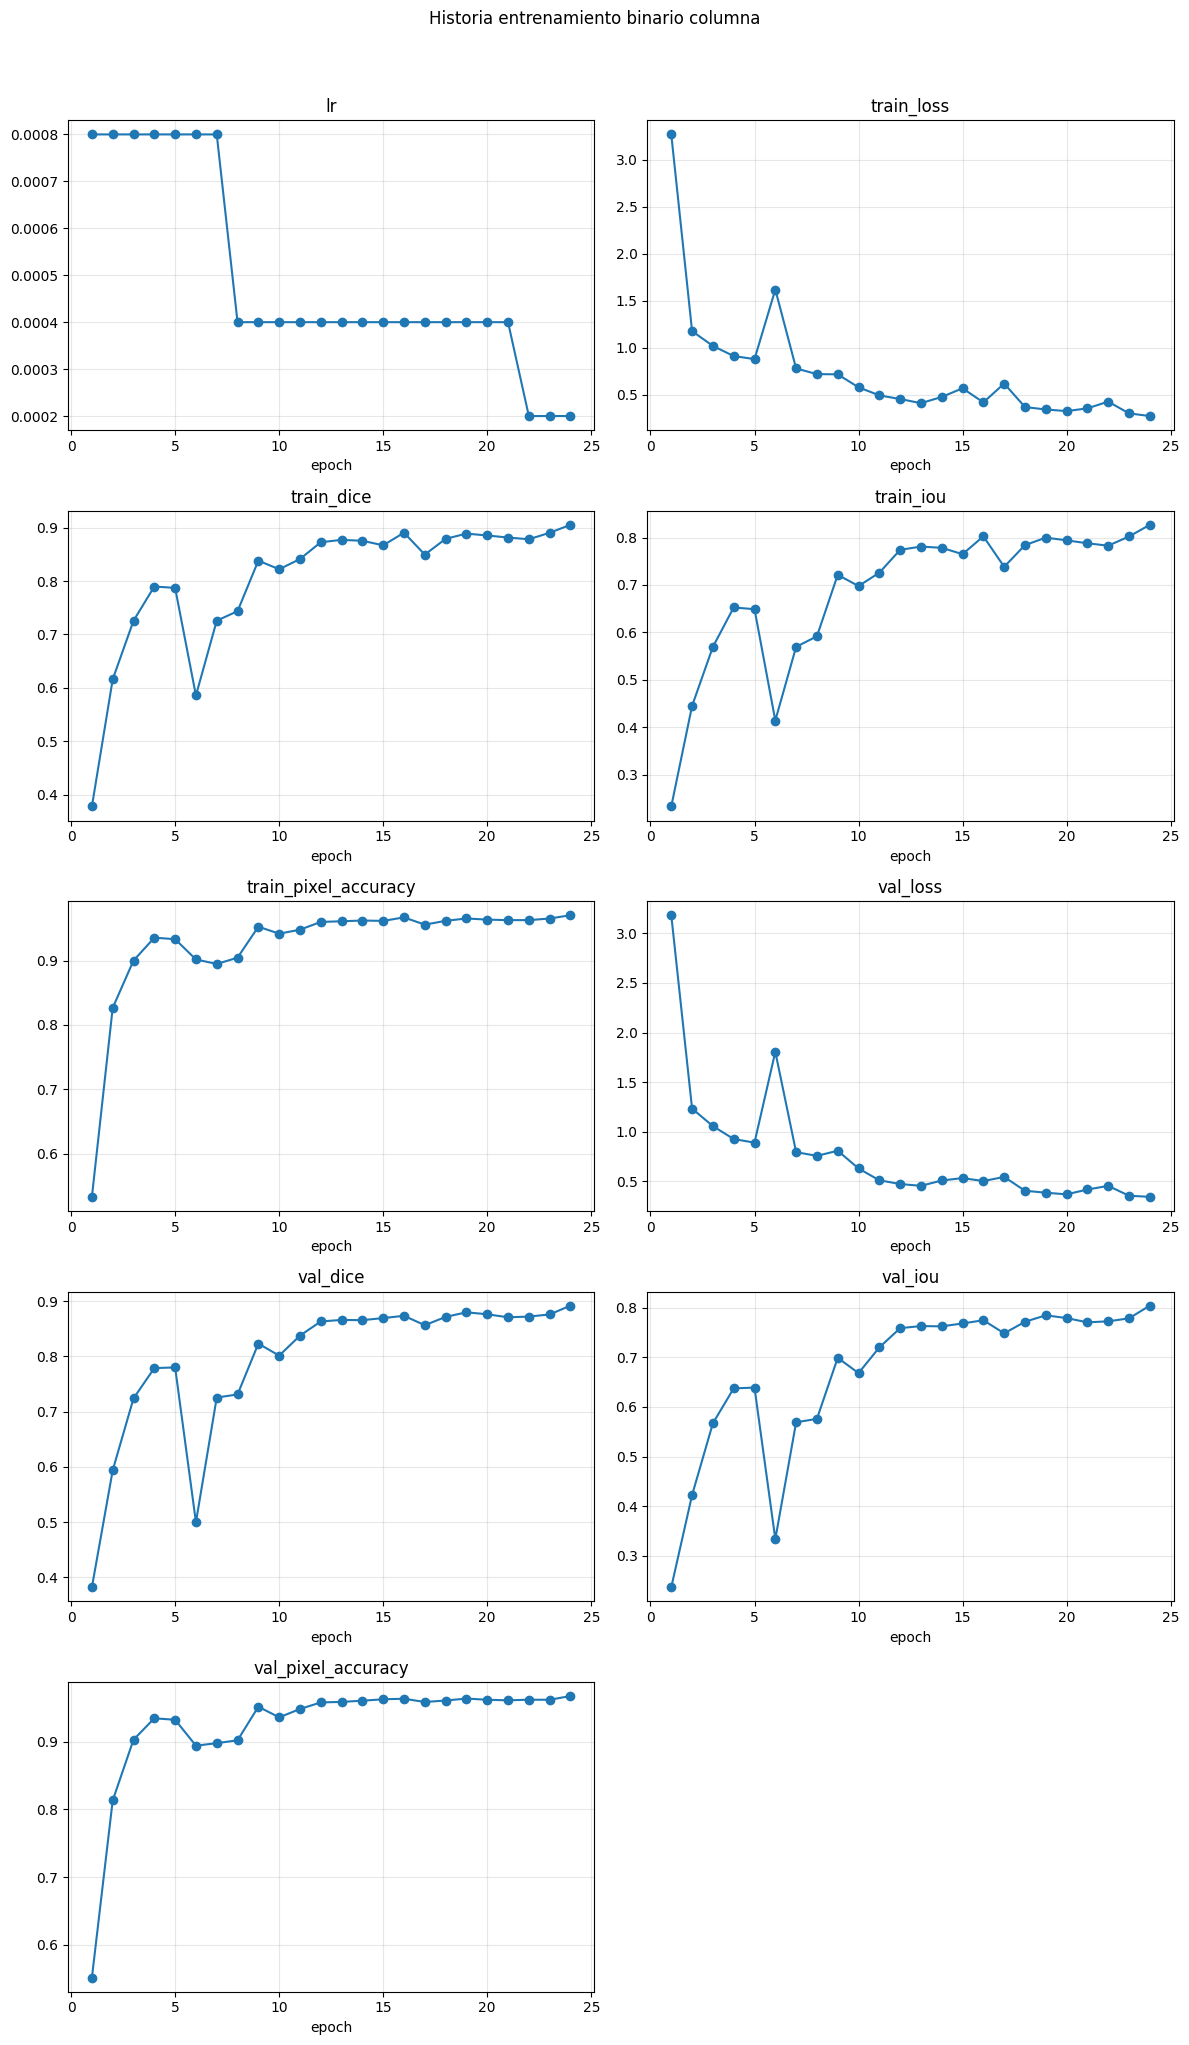

In [5]:
train_ds = BinarySpineDataset(
    binary_splits_df.query("partition == 'train'"),
    image_size=IMG_SIZE,
    apply_hflip=True,
    apply_intensity_aug=True,
)
val_ds = BinarySpineDataset(
    binary_splits_df.query("partition == 'val'"),
    image_size=IMG_SIZE,
    apply_hflip=False,
    apply_intensity_aug=False,
)
test_ds = BinarySpineDataset(
    binary_splits_df.query("partition == 'test'"),
    image_size=IMG_SIZE,
    apply_hflip=False,
    apply_intensity_aug=False,
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

binary_model = UNetSmall(in_channels=1, out_channels=1).to(DEVICE)
binary_optimizer = torch.optim.AdamW(binary_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
pos_weight_value = estimate_binary_pos_weight(binary_splits_df.query("partition == 'train'"))
binary_bce = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight_value], dtype=torch.float32, device=DEVICE))
binary_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    binary_optimizer,
    mode="max",
    factor=0.5,
    patience=2,
)

history = []
best_state = None
best_val_dice = -1.0
epochs_without_improvement = 0
start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    binary_model.train()
    train_loss_sum = 0.0
    train_count = 0

    for batch in train_loader:
        images = batch["image"].to(DEVICE)
        targets = batch["mask"].to(DEVICE)
        binary_optimizer.zero_grad(set_to_none=True)
        logits = binary_model(images)
        loss = binary_bce(logits, targets) + dice_loss_binary(logits, targets)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(binary_model.parameters(), GRAD_CLIP_NORM)
        binary_optimizer.step()
        train_loss_sum += float(loss.item()) * images.size(0)
        train_count += images.size(0)

    train_metrics = evaluate_binary(binary_model, train_loader, binary_bce, threshold=BINARY_THRESHOLD)
    val_metrics = evaluate_binary(binary_model, val_loader, binary_bce, threshold=BINARY_THRESHOLD)
    binary_scheduler.step(val_metrics["dice"])

    history.append({
        "epoch": epoch,
        "lr": float(binary_optimizer.param_groups[0]["lr"]),
        "train_loss": train_metrics["loss"],
        "train_dice": train_metrics["dice"],
        "train_iou": train_metrics["iou"],
        "train_pixel_accuracy": train_metrics["pixel_accuracy"],
        "val_loss": val_metrics["loss"],
        "val_dice": val_metrics["dice"],
        "val_iou": val_metrics["iou"],
        "val_pixel_accuracy": val_metrics["pixel_accuracy"],
    })
    if val_metrics["dice"] > best_val_dice:
        best_val_dice = val_metrics["dice"]
        best_state = {k: v.detach().cpu().clone() for k, v in binary_model.state_dict().items()}
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
    print(
        f"[Binary][Epoch {epoch:02d}/{EPOCHS}] "
        f"lr={binary_optimizer.param_groups[0]['lr']:.6f} "
        f"train_dice={train_metrics['dice']:.4f} "
        f"val_dice={val_metrics['dice']:.4f}"
    )
    if epochs_without_improvement >= PATIENCE_EARLY_STOP:
        print(f"Early stopping activado en epoch {epoch}.")
        break

history_df = pd.DataFrame(history)
binary_model.load_state_dict(best_state)

threshold_sweep_df = sweep_binary_thresholds(
    binary_model,
    val_loader,
    bce_loss=binary_bce,
    thresholds=THRESHOLD_CANDIDATES,
)
best_threshold = float(threshold_sweep_df.iloc[0]["threshold"])
BINARY_THRESHOLD = best_threshold
test_metrics = evaluate_binary(binary_model, test_loader, binary_bce, threshold=best_threshold)
test_metrics["selected_threshold"] = best_threshold
test_metrics["pos_weight"] = pos_weight_value

model_path = MODEL_DIR / "binary_spine_thoracolumbar_best.pt"
metrics_path = OUTPUT_DIR / "binary_spine_test_metrics.csv"
history_path = OUTPUT_DIR / "binary_spine_history.csv"
threshold_metrics_path = OUTPUT_DIR / "binary_spine_threshold_calibration.csv"
threshold_config_path = OUTPUT_DIR / "binary_spine_threshold_config.json"
torch.save(binary_model.state_dict(), model_path)
pd.DataFrame([test_metrics]).to_csv(metrics_path, index=False)
history_df.to_csv(history_path, index=False)
threshold_sweep_df.to_csv(threshold_metrics_path, index=False)
threshold_config_path.write_text(
    json.dumps(
        {
            "selected_threshold": best_threshold,
            "pos_weight": pos_weight_value,
            "candidates": THRESHOLD_CANDIDATES,
        },
        indent=2,
    ),
    encoding="utf-8",
)

print("Checkpoint guardado en:", model_path)
print("Threshold calibrado:", round(best_threshold, 4))
print("pos_weight usado:", round(pos_weight_value, 4))
print("Tiempo total (min):", round((time.time() - start_time) / 60.0, 2))
print("Mejor val_dice:", round(best_val_dice, 4))
display(history_df.tail())
display(threshold_sweep_df)
display(pd.DataFrame([test_metrics]))
plot_history(history_df, "Historia entrenamiento binario columna")


## 5. Revision cualitativa

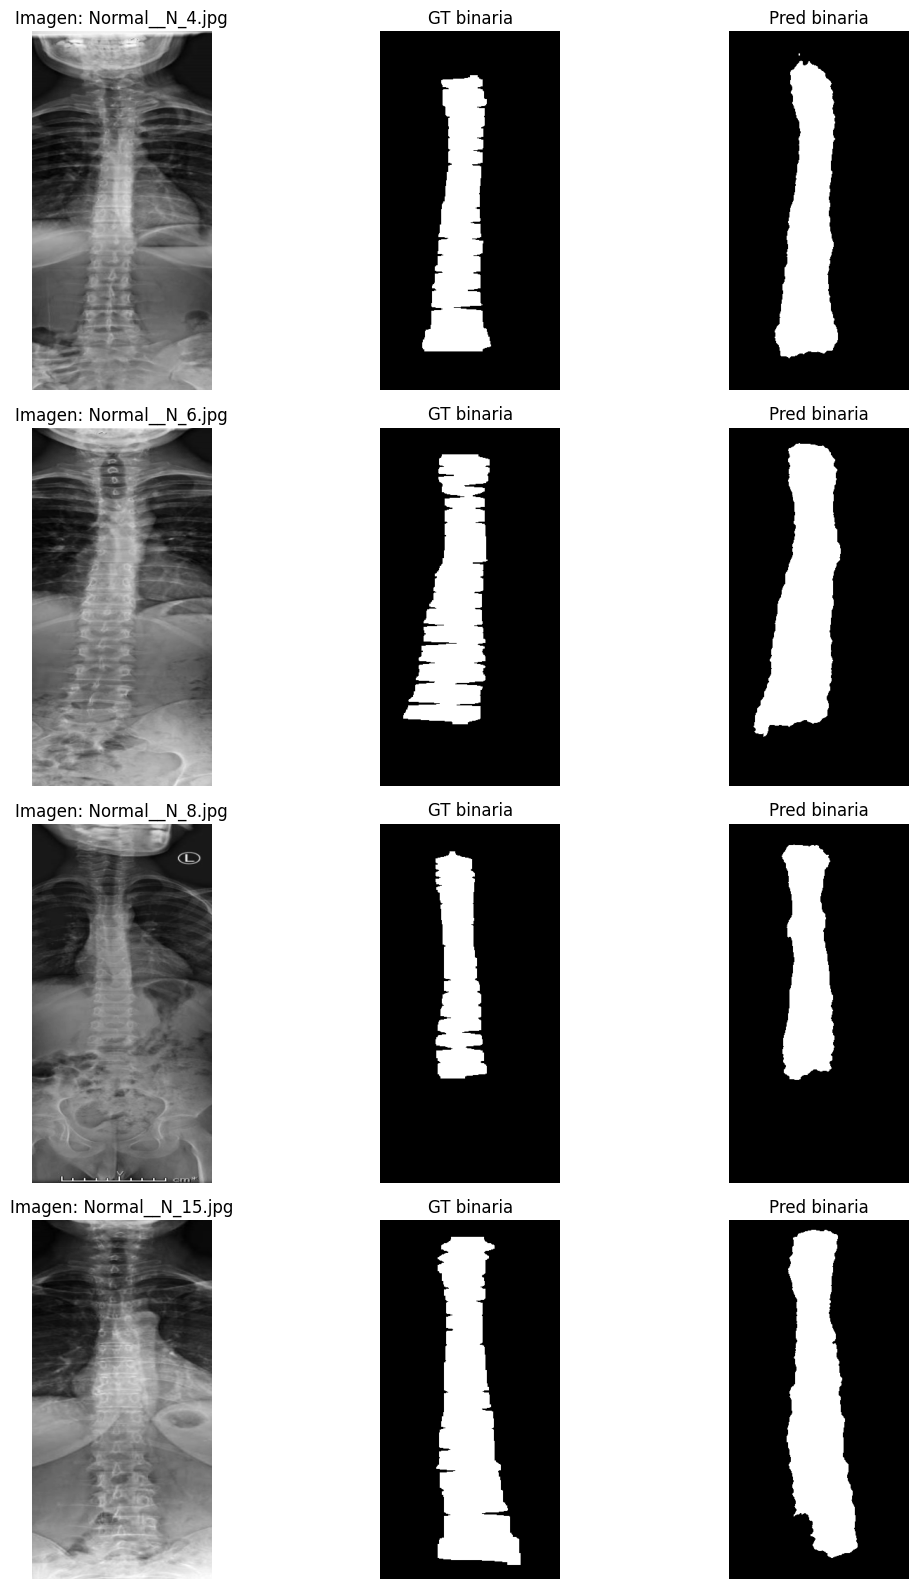

In [6]:
def show_binary_predictions(model: nn.Module, dataset: Dataset, n: int = 4) -> None:
    model.eval()
    n = min(n, len(dataset))
    fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))
    axes = np.atleast_2d(axes)
    with torch.no_grad():
        for idx in range(n):
            sample = dataset[idx]
            image = sample['image'].unsqueeze(0).to(DEVICE)
            target = sample['mask'][0].numpy()
            pred = (torch.sigmoid(model(image))[0, 0].detach().cpu().numpy() >= BINARY_THRESHOLD).astype(np.uint8)
            axes[idx, 0].imshow(sample['image'][0].numpy(), cmap='gray')
            axes[idx, 0].set_title(f"Imagen: {sample['sample_id']}")
            axes[idx, 1].imshow(target, cmap='gray')
            axes[idx, 1].set_title('GT binaria')
            axes[idx, 2].imshow(pred, cmap='gray')
            axes[idx, 2].set_title('Pred binaria')
            for j in range(3):
                axes[idx, j].axis('off')
    plt.tight_layout()
    plt.show()


show_binary_predictions(binary_model, test_ds, n=4)

Sí, con estos resultados yo sí continuaría al siguiente notebook. No veo un bloqueo fuerte en el entrenamiento binario.

Lo más importante que salió:

best val_dice = 0.8285
test dice = 0.8440
test IoU = 0.7301
test pixel_accuracy = 0.9560
el entrenamiento terminó en ~6.22 minutos en cuda
Lectura técnica:

para la etapa binaria, un Dice de ~0.84 es una base razonable para pasar a cascada
el modelo sí aprendió bien la localización de la columna
la validación y el test están bastante alineados, y eso es buena señal
sí hubo oscilaciones visibles en épocas 5-6 y 13, así que el entrenamiento no fue totalmente estable, pero logró recuperarse y el mejor checkpoint quedó bien
Lo que me llama la atención:

el split quedó desbalanceado entre Normal y Scoliosis
en validación solo quedaron 6 casos Normal vs 34 Scoliosis
eso puede volver un poco ruidosa la lectura de val_dice, aunque para binario no es necesariamente crítico
Mi conclusión:

no haría un reentrenamiento del binario por ahora
sí avanzaría al notebook de cascada
el binario actual ya parece suficientemente bueno para generar ROI y probar identificación de vértebras